In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

from langchain_openai import ChatOpenAI
# from langchain.chains import create_sql_query_chain
from langchain_classic.chains import create_sql_query_chain
llm_gpt = ChatOpenAI(model='gpt-4o', temperature=0)

/Users/shudhanshu/Desktop/Study Projects/GenAI/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [2]:
from langchain_community.utilities import SQLDatabase

In [3]:
db = SQLDatabase.from_uri("sqlite:///ComicStore.db")
db

In [4]:
from langchain_community.agent_toolkits import SQLDatabaseToolkit

In [6]:
sql_toolkit = SQLDatabaseToolkit(
    db=db,
    llm=llm_gpt
)

sql_tools = sql_toolkit.get_tools()
sql_tools

[QuerySQLDatabaseTool(description="Input to this tool is a detailed and correct SQL query, output is a result from the database. If the query is not correct, an error message will be returned. If an error is returned, rewrite the query, check the query, and try again. If you encounter an issue with Unknown column 'xxxx' in 'field list', use sql_db_schema to query the correct table fields.", db=<langchain_community.utilities.sql_database.SQLDatabase object at 0x10a4f0a40>),
 InfoSQLDatabaseTool(description='Input to this tool is a comma-separated list of tables, output is the schema and sample rows for those tables. Be sure that the tables actually exist by calling sql_db_list_tables first! Example Input: table1, table2, table3', db=<langchain_community.utilities.sql_database.SQLDatabase object at 0x10a4f0a40>),
 ListSQLDatabaseTool(db=<langchain_community.utilities.sql_database.SQLDatabase object at 0x10a4f0a40>),
 QuerySQLCheckerTool(description='Use this tool to double check if your 

In [7]:
for tool in sql_tools:
    print(tool.name, '->', tool.description)

sql_db_query -> Input to this tool is a detailed and correct SQL query, output is a result from the database. If the query is not correct, an error message will be returned. If an error is returned, rewrite the query, check the query, and try again. If you encounter an issue with Unknown column 'xxxx' in 'field list', use sql_db_schema to query the correct table fields.
sql_db_schema -> Input to this tool is a comma-separated list of tables, output is the schema and sample rows for those tables. Be sure that the tables actually exist by calling sql_db_list_tables first! Example Input: table1, table2, table3
sql_db_list_tables -> Input is an empty string, output is a comma-separated list of tables in the database.
sql_db_query_checker -> Use this tool to double check if your query is correct before executing it. Always use this tool before executing a query with sql_db_query!


In [9]:
from langchain_core.messages import SystemMessage

In [10]:
SQL_PREFIX = """
    You are agent designed to interact with a SQL database in SQLite.
    Given an input question, first create a syntactically corrrect SQLite query to run,
    then look at the results of the query and return the answer to the input question.

    Unless the user specifies in the question a specific number of examples they wish to obtain,
    always limit your query to at most 10 results.

    You can order the results by a relevant column to return the most interesting example in the database.
    Never query for all columns from a specific table, only ask for the relevant columns given the question.
    Make sure you generate a correct SQLite query as plain text without any formatting or code blocks.

    Do not include sql or similar markers.
    Do not try to explain the query, just provided the query as-is, like this: SELECT ...

    You have access to tools for interacting with the database.
    Only use the below tools. Only use the information returned by the below tools to construct your final answer.
    
    You MUST double check your query before executing it. If you get an error while executing a query, rewrite the query and try again.
    DO NOT make any DML statements (INSERT, UPDATE, DELETE, DROP etc.) to the database even if the user asks.

    To start you should ALWAYS look at the tables in the database to see what you can query.
    Do NOT skip this step.

    When generating the final answer in the markdown from the results,
    if there are special characters in the text, such as the dollar symbol,
    ensure they are escaped properly for the correct rendering e.g $25.5 should become \$25.5


"""

SYS_PROMPT = SystemMessage(content=SQL_PREFIX)

<>:1: SyntaxWarning: invalid escape sequence '\$'
<>:1: SyntaxWarning: invalid escape sequence '\$'
/var/folders/v6/yl2g8s4j2837v29lvdsbtzwm0000gp/T/ipykernel_87623/1289694519.py:1: SyntaxWarning: invalid escape sequence '\$'
  SQL_PREFIX = """


In [14]:
from langchain_core.messages import HumanMessage
# from langgraph.prebuilt import create_react_agent
from langchain.agents import create_agent


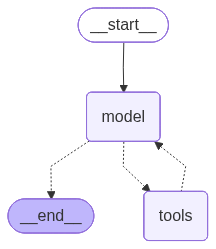

In [16]:
text2sql_agent = create_agent(
    model=llm_gpt,
    tools=sql_tools,
    system_prompt=SYS_PROMPT
    
)

text2sql_agent

In [17]:
from IPython.display import display, Markdown

In [19]:
for s in text2sql_agent.stream(
    {"message":[HumanMessage(content='what is the total number of customers?')]}
):
    display(Markdown(str(s)))
    print("-----")

{'model': {'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 12, 'prompt_tokens': 654, 'total_tokens': 666, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_d59908c1a9', 'id': 'chatcmpl-DW1wCybCskZtVervaJ80WPwXBjJdR', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019da138-512c-72d3-92ff-9d30472ddd26-0', tool_calls=[{'name': 'sql_db_list_tables', 'args': {}, 'id': 'call_hSJnTE4UvoD30VT1CyoiLCYW', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 654, 'output_tokens': 12, 'total_tokens': 666, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]}}

-----


{'tools': {'messages': [ToolMessage(content='Branch, Comic, Customer, Employee, Inventory, Publisher, Sale, SaleTransactions', name='sql_db_list_tables', id='1ebee4cc-f514-4497-93ac-7ca9210b81fc', tool_call_id='call_hSJnTE4UvoD30VT1CyoiLCYW')]}}

-----


{'model': {'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 31, 'prompt_tokens': 692, 'total_tokens': 723, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_d59908c1a9', 'id': 'chatcmpl-DW1wES2pwH6JiFfizWz0cIO6O0FQ3', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019da138-5782-7142-924d-de667cbef7d2-0', tool_calls=[{'name': 'sql_db_schema', 'args': {'table_names': 'Branch, Comic, Customer, Employee, Inventory, Publisher, Sale, SaleTransactions'}, 'id': 'call_L8ZVzoPC4pxu6KAEyIvMy62m', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 692, 'output_tokens': 31, 'total_tokens': 723, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]}}

...

-----


{'tools': {'messages': [ToolMessage(content="[('Transformers: All Hail Megatron', 25.99), ('Hellboy: Seed of Destruction', 24.99), ('Sin City: The Hard Goodbye', 22.99), ('Batman: Hush', 22.99), ('Usagi Yojimbo Volume 1', 20.99), ('Black Hammer Volume 1', 20.99), ('Wolverine: Old Man Logan', 20.99), ('Spider-Man: Homecoming', 19.99), ('Watchmen', 19.99), ('300', 19.99)]", name='sql_db_query', id='d2bccc09-1dec-4c91-8afd-9106656f26f0', tool_call_id='call_t7OlRpreqmT9r0qOkUIcvEcu')]}}

-----


{'model': {'messages': [AIMessage(content='Here are the top 10 most expensive comics:\n\n1. Transformers: All Hail Megatron - \\$25.99\n2. Hellboy: Seed of Destruction - \\$24.99\n3. Sin City: The Hard Goodbye - \\$22.99\n4. Batman: Hush - \\$22.99\n5. Usagi Yojimbo Volume 1 - \\$20.99\n6. Black Hammer Volume 1 - \\$20.99\n7. Wolverine: Old Man Logan - \\$20.99\n8. Spider-Man: Homecoming - \\$19.99\n9. Watchmen - \\$19.99\n10. 300 - \\$19.99', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 141, 'prompt_tokens': 2404, 'total_tokens': 2545, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_d59908c1a9', 'id': 'chatcmpl-DW1wJqHoMQPWGdBZVAfmVZhrIqqG2', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019da138-6bdd-7d60-a6b0-38cc83238d29-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 2404, 'output_tokens': 141, 'total_tokens': 2545, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]}}

-----


In [21]:
for event in text2sql_agent.stream(
    {"message":[HumanMessage(content='what are the top 10 most popular comics?')]}, stream_mode='values' #returns full agent state with all messsages including updates
):
    event["messages"][-1].pretty_print()

print('\n\nFinal Response:\n')
display(Markdown(event["messages"][-1].content))
    

================================== Ai Message ==================================
Tool Calls:
  sql_db_list_tables (call_w8bA672OtyCbjd4mX0Vcebx2)
 Call ID: call_w8bA672OtyCbjd4mX0Vcebx2
  Args:
================================= Tool Message =================================
Name: sql_db_list_tables

Branch, Comic, Customer, Employee, Inventory, Publisher, Sale, SaleTransactions
================================== Ai Message ==================================
Tool Calls:
  sql_db_schema (call_NpBEYROV7UDpYzF5Ov3iPSvQ)
 Call ID: call_NpBEYROV7UDpYzF5Ov3iPSvQ
  Args:
    table_names: Branch, Comic, Customer, Employee, Inventory, Publisher, Sale, SaleTransactions
================================= Tool Message =================================
Name: sql_db_schema


CREATE TABLE "Branch" (
	"BranchId" INTEGER NOT NULL, 
	"Name" NVARCHAR(100) NOT NULL, 
	"City" NVARCHAR(50) NOT NULL, 
	"State" NVARCHAR(50), 
	"Country" NVARCHAR(50) NOT NULL, 
	"PostalCode" NVARCHAR(10), 
	PRIMARY KEY ("BranchI

The comic titled "Spider-Man: Homecoming" is a Superhero genre comic, priced at \$19.99, and was released on July 7, 2017.

In [22]:
def call_text2sql_agent(query, verbose=False):
    for event in text2sql_agent.stream(
    {"message":[HumanMessage(content='what are the top 10 most popular comics?')]}, stream_mode='values'
    ):
        if verbose:
            event["messages"][-1].pretty_print()
    
    print('\n\nFinal Response:\n')
    display(Markdown(event["messages"][-1].content))
    

In [23]:
call_text2sql_agent(query="what is the most popular comic?")



Final Response:



The "Central Comics" branch currently has a total of 745 comics in stock.